# Assignment 8 — Variational Autoencoder (VAE) on MNIST with a 2-D Latent Space

**Goal:** understand how a VAE organises its latent space.
We deliberately use a **2-dimensional latent space** so the whole latent space can be drawn on a plain 2-D graph.

**Plan**
1. Load MNIST and build a VAE (encoder → μ, log σ² → reparameterise → decoder).
2. Train for 20 epochs, recording **reconstruction loss** and **KL-divergence loss** *separately*.
3. Encode the test images and plot their 2-D latent positions, coloured by digit label (0–9).
4. Decode a regular grid of points in [−3, +3] × [−3, +3] into images.
5. Answer the observation questions.

**Loss used**  (standard VAE, β = 1), averaged per image:

$$\mathcal{L} = \underbrace{\text{BCE}(x,\hat{x})}_{\text{reconstruction}} \;+\; \underbrace{-\tfrac12\sum_{j}\left(1+\log\sigma_j^2-\mu_j^2-\sigma_j^2\right)}_{\text{KL}(q(z|x)\,\|\,\mathcal{N}(0,I))}$$

## 1. Setup

In [1]:
import time, random
import numpy as np
import matplotlib.pyplot as plt
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch", torch.__version__, "| device:", device)

LATENT_DIM = 2      # 2-D on purpose, so we can plot it
EPOCHS     = 20
BATCH_SIZE = 128
LR         = 1e-3

PyTorch 2.14.0+cu130 | device: cpu


## 2. Load MNIST

In [2]:
train_ds = datasets.MNIST("./data", train=True,  download=True)
test_ds  = datasets.MNIST("./data", train=False, download=True)

# pixels scaled to [0, 1], flattened 28x28 -> 784
x_train = train_ds.data.float().div(255).view(-1, 784);  y_train = train_ds.targets
x_test  = test_ds.data.float().div(255).view(-1, 784);   y_test  = test_ds.targets
print("train:", tuple(x_train.shape), "| test:", tuple(x_test.shape))

train_loader = DataLoader(TensorDataset(x_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(TensorDataset(x_test,  y_test),  batch_size=1000, shuffle=False)

train: (60000, 784) | test: (10000, 784)


## 3. The VAE

* **Encoder:** 784 → 512 → 256, then two linear heads that output **μ** and **log σ²** (each 2-D).
* **Reparameterisation trick:** `z = μ + σ · ε`, with `ε ~ N(0, I)`, so gradients can flow through the sampling step.
* **Decoder:** 2 → 256 → 512 → 784 with a sigmoid output (pixel intensities in [0, 1]).

In [3]:
class VAE(nn.Module):
    def __init__(self, latent_dim=2):
        super().__init__()
        self.enc = nn.Sequential(nn.Linear(784, 512), nn.ReLU(),
                                 nn.Linear(512, 256), nn.ReLU())
        self.fc_mu     = nn.Linear(256, latent_dim)
        self.fc_logvar = nn.Linear(256, latent_dim)
        self.dec = nn.Sequential(nn.Linear(latent_dim, 256), nn.ReLU(),
                                 nn.Linear(256, 512), nn.ReLU(),
                                 nn.Linear(512, 784), nn.Sigmoid())

    def encode(self, x):
        h = self.enc(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        return mu + std * torch.randn_like(std)

    def decode(self, z):
        return self.dec(z)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

model = VAE(LATENT_DIM).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
print(model)
print("trainable parameters:", sum(p.numel() for p in model.parameters()))

VAE(
  (enc): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): ReLU()
  )
  (fc_mu): Linear(in_features=256, out_features=2, bias=True)
  (fc_logvar): Linear(in_features=256, out_features=2, bias=True)
  (dec): Sequential(
    (0): Linear(in_features=2, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=784, bias=True)
    (5): Sigmoid()
  )
)
trainable parameters: 1068820


## 4. Loss function — reconstruction and KL kept **separate**

Both terms are summed over pixels / latent dimensions and then averaged over the images in the batch,
so the numbers are "nats per image" and easy to compare between epochs.

In [4]:
def vae_loss(x_hat, x, mu, logvar):
    recon = F.binary_cross_entropy(x_hat, x, reduction="sum") / x.size(0)
    kl    = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / x.size(0)
    return recon, kl

## 5. Train for 20 epochs (recording recon and KL every epoch)

In [5]:
history = {"train_recon": [], "train_kl": [], "test_recon": [], "test_kl": []}

def run_epoch(loader, train):
    model.train(train)
    tot_r = tot_k = n = 0
    with torch.set_grad_enabled(train):
        for xb, _ in loader:
            xb = xb.to(device)
            x_hat, mu, logvar = model(xb)
            recon, kl = vae_loss(x_hat, xb, mu, logvar)
            if train:
                optimizer.zero_grad()
                (recon + kl).backward()
                optimizer.step()
            tot_r += recon.item() * xb.size(0)
            tot_k += kl.item()    * xb.size(0)
            n += xb.size(0)
    return tot_r / n, tot_k / n

t0 = time.time()
print(f"{'epoch':>5} | {'train recon':>11} {'train KL':>9} {'train total':>11} | {'test recon':>10} {'test KL':>8} {'test total':>10}")
for epoch in range(1, EPOCHS + 1):
    tr_r, tr_k = run_epoch(train_loader, train=True)
    te_r, te_k = run_epoch(test_loader,  train=False)
    for k, v in zip(history, (tr_r, tr_k, te_r, te_k)):
        history[k].append(v)
    print(f"{epoch:5d} | {tr_r:11.2f} {tr_k:9.2f} {tr_r+tr_k:11.2f} | {te_r:10.2f} {te_k:8.2f} {te_r+te_k:10.2f}")
print(f"\nfinished in {time.time()-t0:.0f}s")

epoch | train recon  train KL train total | test recon  test KL test total


    1 |      176.36      4.19      180.55 |     158.78     5.16     163.94


    2 |      153.92      5.39      159.32 |     150.31     5.70     156.01


    3 |      148.30      5.70      154.01 |     147.27     5.55     152.82


    4 |      144.86      5.93      150.80 |     144.04     5.87     149.91


...

   16 |      133.87      6.63      140.51 |     135.22     6.68     141.90


   17 |      133.54      6.67      140.21 |     135.30     6.63     141.93


   18 |      133.52      6.67      140.19 |     134.90     6.68     141.58


   19 |      133.09      6.72      139.82 |     135.10     6.67     141.76


   20 |      132.90      6.74      139.64 |     135.01     6.65     141.67

finished in 214s


### Loss curves

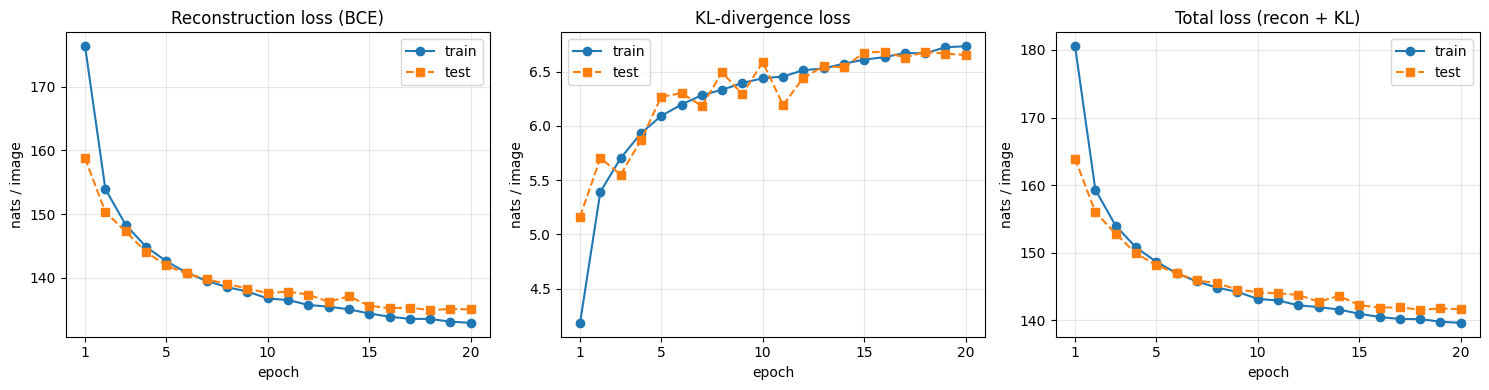

In [6]:
ep = np.arange(1, EPOCHS + 1)
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

ax[0].plot(ep, history["train_recon"], "o-", label="train"); ax[0].plot(ep, history["test_recon"], "s--", label="test")
ax[0].set_title("Reconstruction loss (BCE)")

ax[1].plot(ep, history["train_kl"], "o-", label="train"); ax[1].plot(ep, history["test_kl"], "s--", label="test")
ax[1].set_title("KL-divergence loss")

tot_tr = np.array(history["train_recon"]) + np.array(history["train_kl"])
tot_te = np.array(history["test_recon"])  + np.array(history["test_kl"])
ax[2].plot(ep, tot_tr, "o-", label="train"); ax[2].plot(ep, tot_te, "s--", label="test")
ax[2].set_title("Total loss (recon + KL)")

for a in ax:
    a.set_xlabel("epoch"); a.set_ylabel("nats / image"); a.grid(alpha=.3); a.legend()
    a.set_xticks([1, 5, 10, 15, 20])
plt.tight_layout()
plt.savefig("loss_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Latent-space scatter plot of the test set

Each test image is passed through the encoder. We plot the **mean μ** of q(z|x) (the encoder's best guess of where
the image lives); using μ rather than a random sample keeps the picture free of sampling noise.

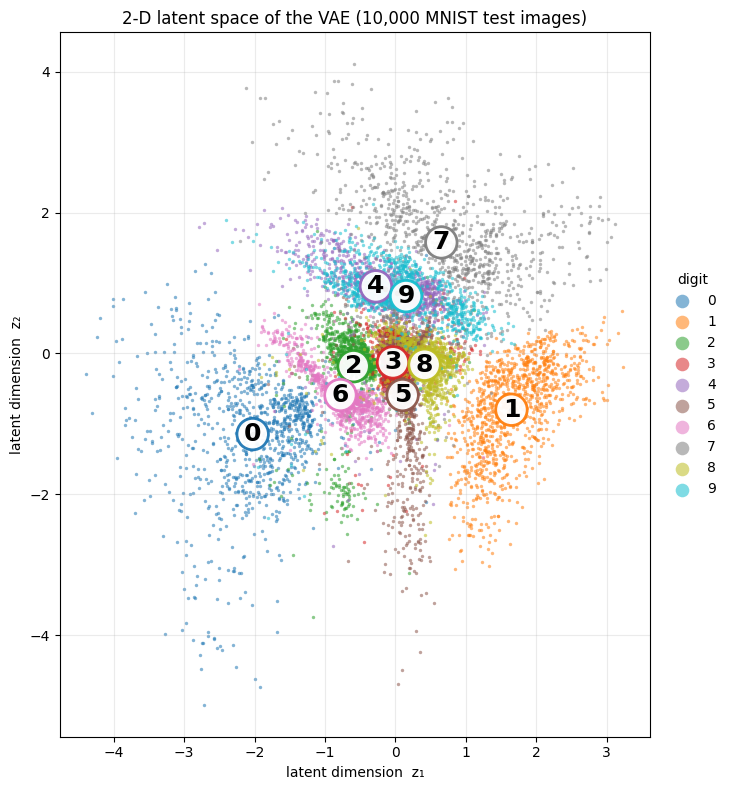

latent range  z1: [-4.39, 3.23]   z2: [-4.99, 4.10]
fraction of test points inside [-3, 3]^2: 97.8%


In [7]:
@torch.no_grad()
def encode_dataset(x):
    model.eval()
    mus = []
    for i in range(0, len(x), 2000):
        mu, _ = model.encode(x[i:i+2000].to(device))
        mus.append(mu.cpu())
    return torch.cat(mus).numpy()

z_test  = encode_dataset(x_test)
labels  = y_test.numpy()

# class centroids (used to annotate the plot and in the analysis below)
centroids = np.array([z_test[labels == d].mean(0) for d in range(10)])

def draw_centroid_labels(ax, fontsize=16, min_dist=0.40):
    # Write each digit at its class centroid. Labels that would overlap are nudged apart
    # (display only) and joined to the true centroid (small dot) by a thin line.
    pos = centroids.copy()
    for _ in range(300):
        moved = False
        for i in range(10):
            for j in range(i + 1, 10):
                v = pos[j] - pos[i]; d = np.linalg.norm(v)
                if d < min_dist:
                    v, d = (np.array([1.0, 0.0]), 1.0) if d < 1e-6 else (v, d)
                    push = (min_dist - d) / 2 * v / d
                    pos[i] -= push; pos[j] += push; moved = True
        if not moved: break
    for d in range(10):
        ax.plot(*centroids[d], "o", color="black", ms=3, zorder=4)
        if np.linalg.norm(pos[d] - centroids[d]) > 0.02:
            ax.plot(*zip(centroids[d], pos[d]), color="black", lw=0.8, zorder=4)
        ax.text(*pos[d], str(d), fontsize=fontsize, fontweight="bold", ha="center", va="center", zorder=5,
                bbox=dict(boxstyle="circle,pad=0.15", fc="white", ec=cmap(d), lw=2, alpha=0.95))

cmap = plt.get_cmap("tab10")
fig, ax = plt.subplots(figsize=(9, 8))
for d in range(10):
    m = labels == d
    ax.scatter(z_test[m, 0], z_test[m, 1], s=6, alpha=0.55, color=cmap(d), label=str(d), linewidths=0)
draw_centroid_labels(ax, fontsize=18, min_dist=0.45)
ax.set_xlabel("latent dimension  z₁"); ax.set_ylabel("latent dimension  z₂")
ax.set_title("2-D latent space of the VAE (10,000 MNIST test images)")
ax.grid(alpha=.25); ax.set_aspect("equal")
leg = ax.legend(title="digit", markerscale=4, loc="center left", bbox_to_anchor=(1.01, 0.5), frameon=False)
plt.tight_layout()
plt.savefig("latent_space_scatter.png", dpi=170, bbox_inches="tight")
plt.show()

print("latent range  z1: [%.2f, %.2f]   z2: [%.2f, %.2f]" % (z_test[:,0].min(), z_test[:,0].max(), z_test[:,1].min(), z_test[:,1].max()))
inside = np.mean((np.abs(z_test) <= 3).all(1))
print(f"fraction of test points inside [-3, 3]^2: {inside:.1%}")

## 7. Decoded image grid — walking through the latent space

We lay a regular 20 × 20 grid over z ∈ [−3, +3]² and decode every grid point.
**z₁ increases to the right, z₂ increases upward**, exactly like the scatter plot, so the two figures can be compared directly.

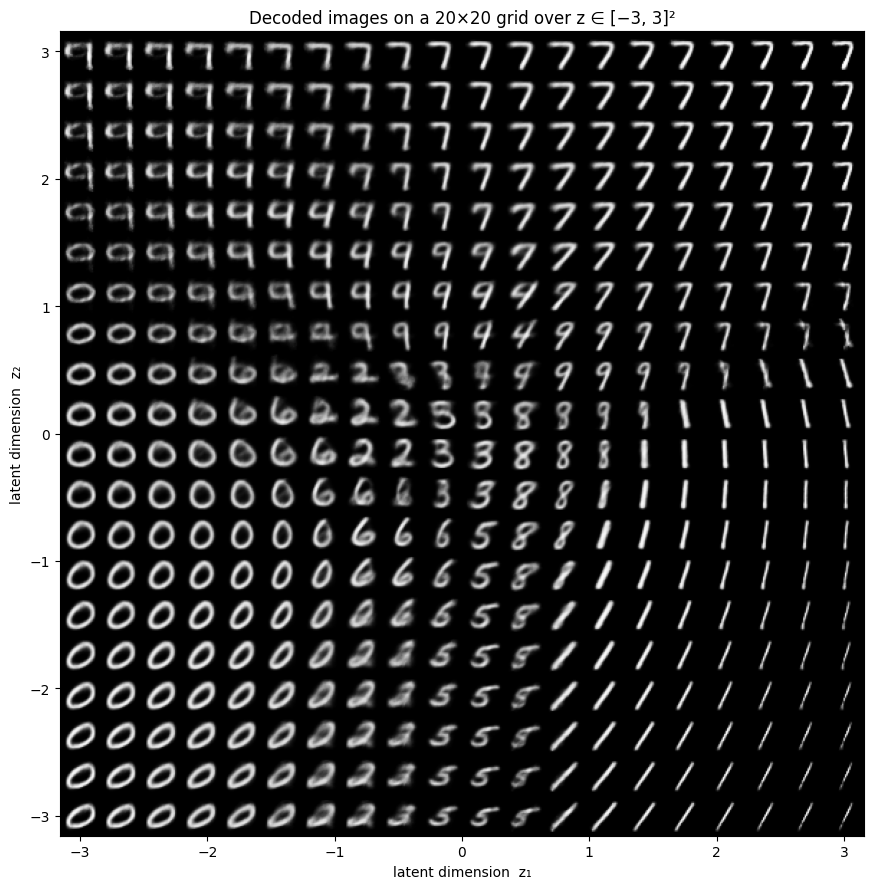

In [8]:
N, LIM = 20, 3.0
gx = np.linspace(-LIM, LIM, N)          # z1: left -> right
gy = np.linspace( LIM, -LIM, N)         # z2: top  -> bottom (so +z2 is up)

with torch.no_grad():
    model.eval()
    zs = torch.tensor([[x, y] for y in gy for x in gx], dtype=torch.float32, device=device)
    grid_imgs = model.decode(zs).cpu().view(N, N, 28, 28).numpy()

canvas = grid_imgs.transpose(0, 2, 1, 3).reshape(N * 28, N * 28)
step = 2 * LIM / (N - 1)
ext = [-LIM - step/2, LIM + step/2, -LIM - step/2, LIM + step/2]

fig, ax = plt.subplots(figsize=(9, 9))
ax.imshow(canvas, cmap="gray", extent=ext, origin="upper")
ticks = np.linspace(-LIM, LIM, 7)
ax.set_xticks(ticks); ax.set_yticks(ticks)
ax.set_xlabel("latent dimension  z₁"); ax.set_ylabel("latent dimension  z₂")
ax.set_title(f"Decoded images on a {N}×{N} grid over z ∈ [−3, 3]²")
plt.tight_layout()
plt.savefig("decoded_grid.png", dpi=170, bbox_inches="tight")
plt.show()

### Side-by-side: where the data lives vs. what the decoder draws there

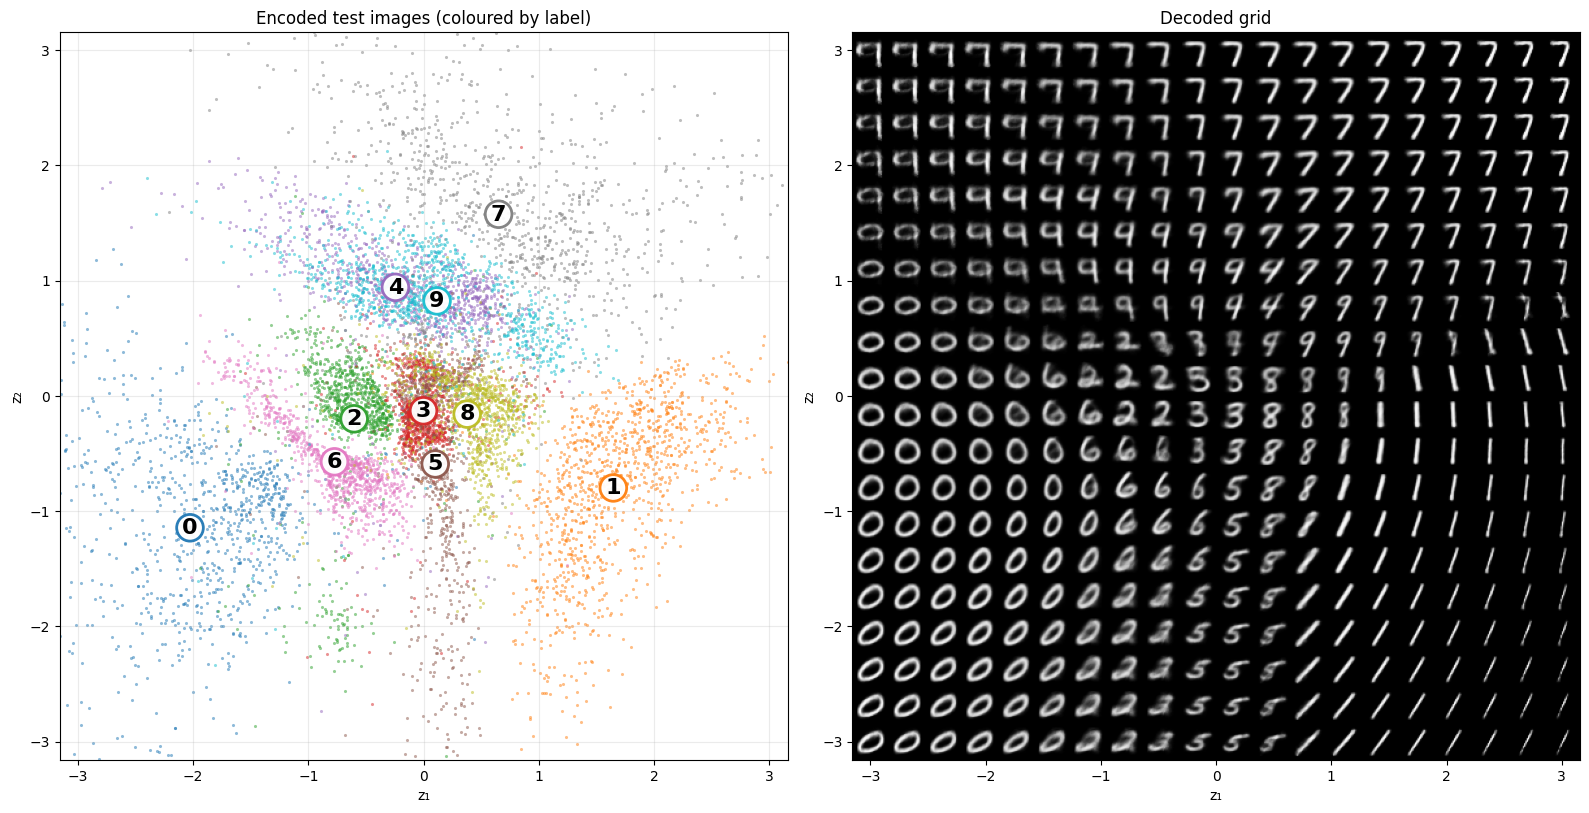

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(16, 8))
for d in range(10):
    m = labels == d
    ax[0].scatter(z_test[m, 0], z_test[m, 1], s=5, alpha=0.5, color=cmap(d), linewidths=0)
draw_centroid_labels(ax[0], fontsize=16, min_dist=0.38)
ax[0].set_xlim(-LIM - step/2, LIM + step/2); ax[0].set_ylim(-LIM - step/2, LIM + step/2)
ax[0].set_aspect("equal"); ax[0].set_title("Encoded test images (coloured by label)"); ax[0].grid(alpha=.25)

ax[1].imshow(canvas, cmap="gray", extent=ext, origin="upper")
ax[1].set_title("Decoded grid")
for a in ax:
    a.set_xlabel("z₁"); a.set_ylabel("z₂")
plt.tight_layout()
plt.savefig("latent_vs_decoded.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Putting numbers on the observations

Looking at pictures is useful, but let's also measure:

* **Clustering / separation** – silhouette score and a 5-nearest-neighbour classifier that uses *only the 2 latent numbers* to guess the digit.
  (If digits sat in clean, separate clusters, this classifier would be near-perfect.)
* **Smoothness** – how different are decoded images of *neighbouring* grid points compared with *random* pairs?

In [10]:
from sklearn.metrics import silhouette_score, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier

z_train = encode_dataset(x_train)
knn = KNeighborsClassifier(n_neighbors=5).fit(z_train, y_train.numpy())
pred = knn.predict(z_test)
acc  = (pred == labels).mean()
sil  = silhouette_score(z_test, labels)

print(f"silhouette score (labels, 2-D latent) : {sil:.3f}   (1 = perfectly separated, 0 = overlapping)")
print(f"5-NN accuracy from 2 latent numbers   : {acc:.1%}   (chance = 10%)\n")

cm = confusion_matrix(labels, pred)
recall = cm.diagonal() / cm.sum(1)
print("per-digit recall (how cleanly each digit's cluster is recovered):")
for d in np.argsort(-recall):
    print(f"  digit {d}: {recall[d]:.1%}")

# most-confused pairs
off = cm.copy(); np.fill_diagonal(off, 0)
pairs = sorted(((off[i, j] + off[j, i], i, j) for i in range(10) for j in range(i+1, 10)), reverse=True)[:6]
print("\nmost-confused digit pairs (total mistakes in both directions):")
for c, i, j in pairs:
    print(f"  {i} <-> {j}: {c}")

# spread of each class
print("\nclass centroids and within-class spread:")
for d in range(10):
    s = z_test[labels == d].std(0)
    print(f"  digit {d}: centroid = ({centroids[d,0]:+.2f}, {centroids[d,1]:+.2f}),  std = ({s[0]:.2f}, {s[1]:.2f})")

silhouette score (labels, 2-D latent) : 0.084   (1 = perfectly separated, 0 = overlapping)
5-NN accuracy from 2 latent numbers   : 78.5%   (chance = 10%)

per-digit recall (how cleanly each digit's cluster is recovered):
  digit 1: 97.4%
  digit 0: 95.3%
  digit 6: 93.3%
  digit 2: 85.8%
  digit 7: 82.3%
  digit 3: 76.0%
  digit 8: 70.0%
  digit 4: 65.2%
  digit 5: 60.5%
  digit 9: 54.9%

most-confused digit pairs (total mistakes in both directions):
  4 <-> 9: 635
  3 <-> 5: 350
  3 <-> 8: 230
  5 <-> 8: 141
  7 <-> 9: 115
  4 <-> 7: 63

class centroids and within-class spread:
  digit 0: centroid = (-2.03, -1.14),  std = (0.73, 0.89)
  digit 1: centroid = (+1.65, -0.80),  std = (0.53, 0.67)
  digit 2: centroid = (-0.60, -0.20),  std = (0.34, 0.62)
  digit 3: centroid = (+0.00, -0.13),  std = (0.26, 0.35)
  digit 4: centroid = (-0.15, +0.91),  std = (0.63, 0.46)
  digit 5: centroid = (+0.10, -0.59),  std = (0.27, 0.91)
  digit 6: centroid = (-0.77, -0.57),  std = (0.41, 0.38)
  digit 

In [11]:
# ---- smoothness of the decoded grid
diff_h = np.abs(grid_imgs[:, 1:] - grid_imgs[:, :-1]).mean(axis=(2, 3))   # left/right neighbours
diff_v = np.abs(grid_imgs[1:, :] - grid_imgs[:-1, :]).mean(axis=(2, 3))   # up/down neighbours
adjacent = np.concatenate([diff_h.ravel(), diff_v.ravel()])

flat = grid_imgs.reshape(-1, 784)
rng = np.random.default_rng(0)
i, j = rng.integers(0, len(flat), 5000), rng.integers(0, len(flat), 5000)
random_pairs = np.abs(flat[i] - flat[j]).mean(1)

print(f"mean pixel change between NEIGHBOURING grid images : {adjacent.mean():.4f}   (max {adjacent.max():.4f})")
print(f"mean pixel change between RANDOM grid images       : {random_pairs.mean():.4f}")
print(f"-> neighbours differ ~{random_pairs.mean()/adjacent.mean():.1f}x less than random pairs")

mean pixel change between NEIGHBOURING grid images : 0.0318   (max 0.1123)
mean pixel change between RANDOM grid images       : 0.1357
-> neighbours differ ~4.3x less than random pairs


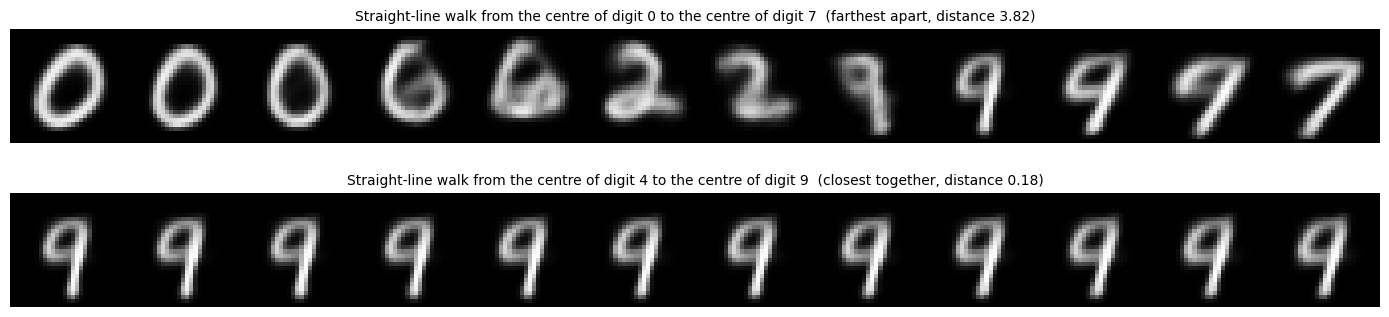

In [12]:
# ---- interpolation strips: farthest pair and nearest pair of class centroids
D = np.linalg.norm(centroids[:, None] - centroids[None], axis=-1)
np.fill_diagonal(D, np.nan)
far  = np.unravel_index(np.nanargmax(D), D.shape)
near = np.unravel_index(np.nanargmin(D), D.shape)

def interp_strip(a, b, steps=12):
    ts = torch.linspace(0, 1, steps).unsqueeze(1)
    z = (1 - ts) * torch.tensor(centroids[a], dtype=torch.float32) + ts * torch.tensor(centroids[b], dtype=torch.float32)
    with torch.no_grad():
        return model.decode(z.to(device)).cpu().view(steps, 28, 28).numpy()

fig, axes = plt.subplots(2, 1, figsize=(14, 3.6))
for ax_, (a, b), name in zip(axes, [far, near], ["farthest apart", "closest together"]):
    strip = interp_strip(a, b)
    ax_.imshow(np.concatenate(list(strip), axis=1), cmap="gray")
    ax_.set_title(f"Straight-line walk from the centre of digit {a} to the centre of digit {b}  ({name}, distance {D[a,b]:.2f})", fontsize=10)
    ax_.axis("off")
plt.tight_layout()
plt.savefig("interpolation_strips.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Written observations

**Setup:** VAE on MNIST, 2-D latent space, MLP encoder/decoder (784→512→256→2 / 2→256→512→784), Adam (lr 1e-3), batch 128, 20 epochs, β = 1. Numbers below come from the executed notebook (seed 42); a re-run on different hardware may differ slightly.

### Training
| | Epoch 1 | Epoch 20 (train) | Epoch 20 (test) |
|---|---|---|---|
| Reconstruction loss | 176.4 | 132.9 | 135.0 |
| KL-divergence loss | 4.2 | 6.7 | 6.7 |
| Total | 180.6 | 139.6 | 141.7 |

Reconstruction loss fell steadily while the KL term **rose** and then levelled off at about 6.7 nats. That is expected: early on the encoder ignores its input (posterior ≈ prior, KL ≈ 0); as it learns to place each image meaningfully, it "spends" KL to store information about the digit. The train/test gap is only about 2 nats, so there is no meaningful overfitting.

### 1. Do similar digits form clusters?
**Yes.** The encoder never saw the labels, yet each digit occupies its own region: 0 on the left, 1 on the lower right, 7 at the top right, 6 and 2 in the left-centre, and 4/9 together above the middle, with 3, 5 and 8 packed in the centre. Digits that look alike are neighbours (4 with 9, 3 with 5 and 8, 6 next to 0), so distance in latent space reflects visual similarity.

### 2. Are the clusters clearly separated?
**Only partly.** 1 (97% recovered), 0 (95%) and 6 (93%) are fairly clean, and 7 is mostly distinct. The rest overlap heavily:
- **4 ↔ 9** are almost on top of each other (centroids only 0.18 apart; 635 confusions).
- **3, 5, 8** overlap in the centre (3↔5: 350, 3↔8: 230 confusions).
- Silhouette score = **0.08** (near 0 means heavy overlap). A 5-nearest-neighbour classifier using only the two latent numbers reaches **78.5%** accuracy. That is far above chance (10%) but well below a standard classifier on full images (over 97%).

Reasons: two dimensions are a tight bottleneck for 10 digit styles; the KL term pulls every cluster toward the same N(0, I) blob, leaving no empty gaps between them; and the VAE is unsupervised, so nothing pushes the classes apart.

### 3. How do generated digits change when moving through the latent space?
Moving left to right along the middle of the grid gives roughly 0 → 6 → 2 → 3/5 → 8 → 1. Going up on the right side gives 1 → 9 → 7. Within a single digit's region the *style* also drifts: the 1s are upright near z₂ ≈ 0 and lean progressively more to the right and get thinner toward the bottom right, and the 0s become more slanted ovals toward the bottom. The scatter plot and the decoded grid line up region for region (0 left, 1 right, 7 top-right).

### 4. Is the transition smooth?
**Mostly yes.** Every point in [−3, 3]² decodes to something digit-like, even where there is almost no test data (e.g. the far bottom-left decodes to a 0), so there are no "holes". Quantitatively, neighbouring grid images differ **4.3× less** (mean pixel change 0.032) than random pairs (0.136). Caveats:
- Between clusters the decoder produces blurry hybrid shapes rather than a clean switch (6→2, the 2/3/5/8 area, 4/9).
- A straight line from the centre of 0 to the centre of 7 (the farthest pair, distance 3.8) passes through 6, 2 and 9, so smooth does not mean direct, and the intermediate glyphs are ambiguous.
- There are a few sharper jumps where large clusters meet (for example 8 → 1 near z₁ ≈ 1; the largest adjacent-cell change is 0.11, about 3.5× the average).
- The centre of the 4 cluster decodes to a 9-like shape, so clean 4s barely appear in the grid. A 2-D latent cannot keep 4 and 9 apart.

### Conclusion
The VAE learned a **continuous, smoothly varying and roughly Gaussian-shaped latent space** that is organised by visual similarity without any labels. The price is a trade-off: the KL regulariser gives smoothness and no gaps, which is good for generation and interpolation, but it pushes classes together and produces blurry outputs at their boundaries. A larger latent size would reduce the overlap and give sharper reconstructions, but could no longer be plotted directly.
